## BC Hydro EV Charging EDA

In [1]:
# Import core and specialist libraries
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

# Preprocessing, metrics, clustering, PCA, t-SNE, and UMAP
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans, DBSCAN
import hdbscan
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.utils import resample
import umap

# Configure plotting styles and disable warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42

print("Setup complete.")

/Users/timothykung/Desktop/Kung_Tim_Lab_Task/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete.


In [2]:
## Load datasets
df_sessions = pd.read_csv("data/sessions.csv")
df_consumption = pd.read_csv("data/consumption.csv")
df_authority_load = pd.read_csv("data/authority_load.csv")

## Sessions Exploration

EV charging sessions data provided by client.

In [3]:
df_sessions.describe()

,duration_hours,energy_kwh,peak_overlap_ratio,battery_soc_start
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,10.129367,25.012033,0.308508,42.904917
std,8.935858,8.054352,0.303486,18.385750
min,1.600000,11.000000,0.000000,10.000000
25%,4.630000,18.140000,0.000000,26.900000
50%,6.730000,24.950000,0.285000,43.050000
75%,11.760000,32.020000,0.470000,58.600000
max,67.650000,39.430000,1.000000,74.900000


In [4]:
df_sessions.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   session_id          1200 non-null   str    
 1   user_id             1200 non-null   str    
 2   housing_type        1200 non-null   str    
 3   charger_level       1200 non-null   str    
 4   start_time          1200 non-null   str    
 5   duration_hours      1200 non-null   float64
 6   energy_kwh          1200 non-null   float64
 7   peak_overlap_ratio  1200 non-null   float64
 8   season              1200 non-null   str    
 9   battery_soc_start   1200 non-null   float64
dtypes: float64(4), str(6)
memory usage: 173.4 KB


In [5]:
df_sessions.head(5)

,session_id,user_id,housing_type,charger_level,start_time,duration_hours,energy_kwh,peak_overlap_ratio,season,battery_soc_start
0,EV-10000,USR-1289,Townhouse,Level 1 (1.4kW),2025-08-14 10:38:00,12.51,17.30,0.42,Winter,60.5
1,EV-10001,USR-1153,Condo/Apartment,Level 2 (7.2kW),2025-07-21 18:49:00,9.99,35.35,0.23,Spring,19.3
2,EV-10002,USR-1086,Single-Family,Level 2 (7.2kW),2025-01-19 17:42:00,7.72,35.62,0.45,Spring,18.7
3,EV-10003,USR-1185,Single-Family,Level 2 (7.2kW),2025-12-01 18:57:00,49.23,14.02,0.19,Winter,68.0
4,EV-10004,USR-1043,Townhouse,Level 2 (7.2kW),2025-06-16 17:19:00,3.21,19.63,1.00,Fall,55.2


In [6]:
## Cleaning / Converting
df_sessions["start_time_datetime_conv"] = pd.to_datetime(df_sessions['start_time'])

In [7]:
df_sessions.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   session_id                1200 non-null   str           
 1   user_id                   1200 non-null   str           
 2   housing_type              1200 non-null   str           
 3   charger_level             1200 non-null   str           
 4   start_time                1200 non-null   str           
 5   duration_hours            1200 non-null   float64       
 6   energy_kwh                1200 non-null   float64       
 7   peak_overlap_ratio        1200 non-null   float64       
 8   season                    1200 non-null   str           
 9   battery_soc_start         1200 non-null   float64       
 10  start_time_datetime_conv  1200 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(4), str(6)
memory usage: 182.7 KB


In [8]:
grouped = df_sessions.groupby('start_time_datetime_conv').count()
grouped

,session_id,user_id,housing_type,charger_level,start_time,duration_hours,energy_kwh,peak_overlap_ratio,season,battery_soc_start
start_time_datetime_conv,,,,,,,,,,
2025-01-01 16:04:00,1,1,1,1,1,1,1,1,1,1
2025-01-01 17:12:00,1,1,1,1,1,1,1,1,1,1
2025-01-01 23:02:00,1,1,1,1,1,1,1,1,1,1
2025-01-02 17:01:00,1,1,1,1,1,1,1,1,1,1
2025-01-02 18:02:00,1,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...
2025-12-30 22:39:00,1,1,1,1,1,1,1,1,1,1
2025-12-31 00:38:00,1,1,1,1,1,1,1,1,1,1
2025-12-31 17:49:00,1,1,1,1,1,1,1,1,1,1


## 30-minute time-of-day aggregation

Bins sessions by time-of-day (ignoring calendar date) into 30-minute buckets to reveal the daily charging demand profile.

In [9]:
df_sessions["time_of_day_30min"] = df_sessions["start_time_datetime_conv"].dt.floor("30min").dt.time

agg_30min = (
    df_sessions.groupby("time_of_day_30min")
    .agg(
        session_count=("session_id", "count"),
        avg_duration_hours=("duration_hours", "mean"),
        avg_energy_kwh=("energy_kwh", "mean"),
        total_energy_kwh=("energy_kwh", "sum"),
        avg_peak_overlap_ratio=("peak_overlap_ratio", "mean"),
        avg_battery_soc_start=("battery_soc_start", "mean"),
    )
    .sort_index()
)

In [10]:
agg_30min.head(5)

,session_count,avg_duration_hours,avg_energy_kwh,total_energy_kwh,avg_peak_overlap_ratio,avg_battery_soc_start
time_of_day_30min,,,,,,
00:00:00,31,8.841290,23.928065,741.77,0.0,45.380645
00:30:00,28,8.414286,23.480000,657.44,0.0,46.403571
01:00:00,3,6.740000,17.113333,51.34,0.0,60.933333
01:30:00,2,5.535000,28.585000,57.17,0.0,34.750000
02:00:00,1,5.680000,14.110000,14.11,0.0,67.800000


### Scatter plots of 30-minute aggregates over time of day

Small multiples (one scatter per metric) since the five measures live on very
different scales (hours, kWh, a 0-1 ratio, and a percentage) — a single shared
y-axis would flatten most of them.

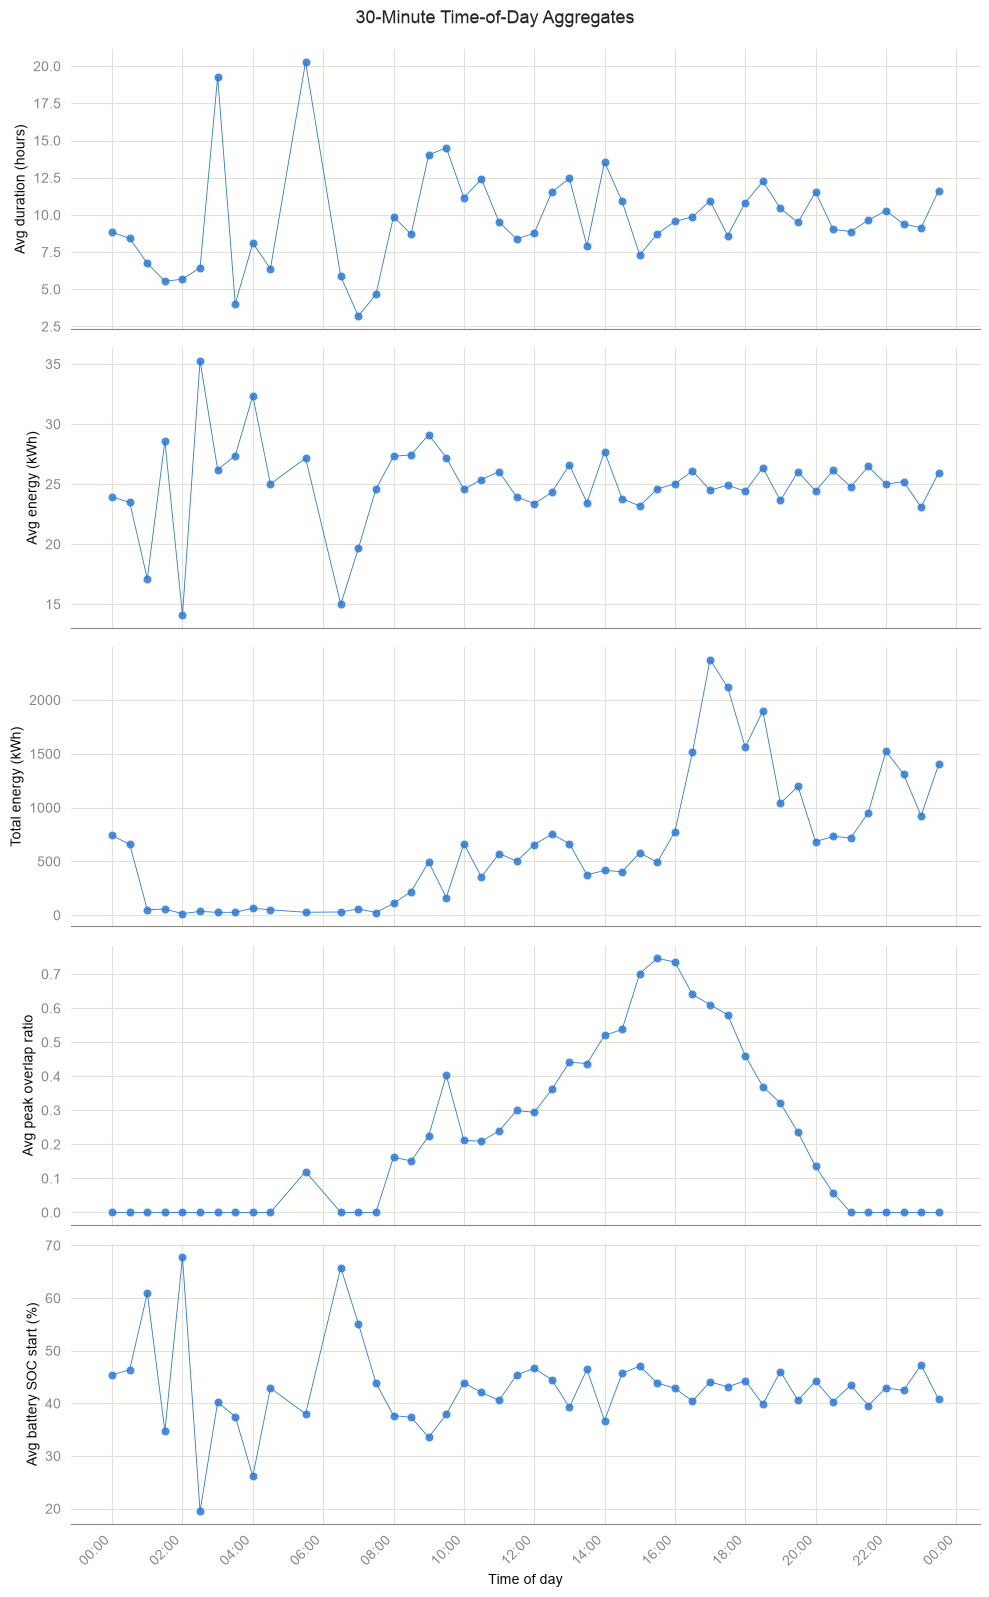

In [11]:
import matplotlib.dates as mdates

# Time-of-day index -> datetime on a dummy day, so matplotlib can treat it as a time axis
x = pd.to_datetime(agg_30min.index.astype(str))

metrics = [
    ("avg_duration_hours", "Avg duration (hours)"),
    ("avg_energy_kwh", "Avg energy (kWh)"),
    ("total_energy_kwh", "Total energy (kWh)"),
    ("avg_peak_overlap_ratio", "Avg peak overlap ratio"),
    ("avg_battery_soc_start", "Avg battery SOC start (%)"),
]

MARK_COLOR = "#2a78d6"
GRID_COLOR = "#e1e0d9"
MUTED = "#898781"

fig, axes = plt.subplots(len(metrics), 1, figsize=(10, 16), sharex=True)

for ax, (col, label) in zip(axes, metrics):
    ax.scatter(x, agg_30min[col], s=40, color=MARK_COLOR, alpha=0.85,
               edgecolor="white", linewidth=0.6, zorder=3)
    ax.plot(x, agg_30min[col], color=MARK_COLOR,linewidth=0.6, zorder=3)
    ax.set_ylabel(label, color="#0b0b0b")
    ax.grid(True, color=GRID_COLOR, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(MUTED)
    ax.tick_params(colors=MUTED)

axes[-1].xaxis.set_major_locator(mdates.HourLocator(interval=2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.setp(axes[-1].get_xticklabels(), rotation=45, ha="right")
axes[-1].set_xlabel("Time of day", color="#0b0b0b")

fig.suptitle("30-Minute Time-of-Day Aggregates", y=0.995, fontsize=13)
fig.tight_layout()
plt.show()

## Day of week and month

Derives calendar features from `start_time_datetime_conv` for later grouping/seasonality analysis.

In [12]:
df_sessions["day_of_week"] = df_sessions["start_time_datetime_conv"].dt.day_name()
df_sessions["month"] = df_sessions["start_time_datetime_conv"].dt.month_name()

df_sessions[["start_time_datetime_conv", "day_of_week", "month"]].head()

,start_time_datetime_conv,day_of_week,month
0,2025-08-14 10:38:00,Thursday,August
1,2025-07-21 18:49:00,Monday,July
2,2025-01-19 17:42:00,Sunday,January
3,2025-12-01 18:57:00,Monday,December
4,2025-06-16 17:19:00,Monday,June


### Total energy usage by month and by day of week

Bar charts of summed `energy_kwh`, with months in calendar order (January–December)
and days in weekday order (Monday–Sunday) rather than alphabetical or first-seen order.

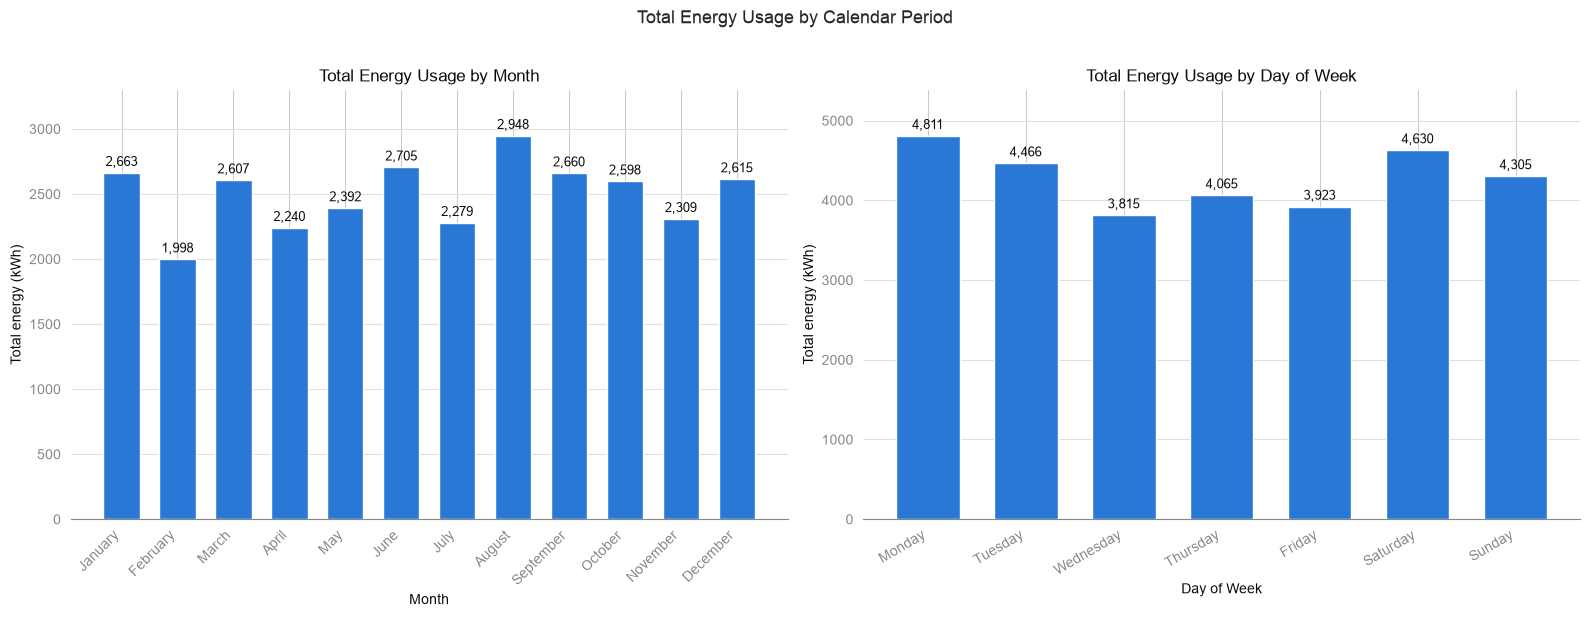

In [13]:
MONTH_ORDER = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December",
]
DAY_ORDER = [
    "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday",
]

energy_by_month = (
    df_sessions.groupby("month")["energy_kwh"].sum().reindex(MONTH_ORDER, fill_value=0)
)
energy_by_day = (
    df_sessions.groupby("day_of_week")["energy_kwh"].sum().reindex(DAY_ORDER, fill_value=0)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

panels = (
    (axes[0], energy_by_month, "Total Energy Usage by Month", "Month", 45),
    (axes[1], energy_by_day, "Total Energy Usage by Day of Week", "Day of Week", 30),
)

for ax, data, title, xlabel, rotation in panels:
    bars = ax.bar(data.index, data.values, color=MARK_COLOR, width=0.65, zorder=3)
    ax.bar_label(
        bars,
        labels=[f"{v:,.0f}" for v in data.values],
        padding=3, fontsize=9, color="#0b0b0b",
    )

    ax.set_title(title, fontsize=12, color="#0b0b0b")
    ax.set_xlabel(xlabel, color="#0b0b0b")
    ax.set_ylabel("Total energy (kWh)", color="#0b0b0b")
    ax.grid(True, axis="y", color=GRID_COLOR, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(MUTED)
    ax.tick_params(colors=MUTED)
    plt.setp(ax.get_xticklabels(), rotation=rotation, ha="right")
    ax.margins(y=0.12)  # headroom so data labels don't clip the top

fig.suptitle("Total Energy Usage by Calendar Period", y=1.02, fontsize=13)
fig.tight_layout()
plt.show()

## Consumption Exploration

Consumption exploration sources by data science team (me, Tim K.) Sourced from: https://energy-information.canada.ca/en/subjects/electricity

The dataset has been already pre-filtered to limit results to BC geography. The column can be considered a dummy.

In [14]:
df_consumption.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Geography                48 non-null     str  
 1   Reference period         48 non-null     str  
 2   3 - value measure (MWh)  48 non-null     str  
dtypes: str(3)
memory usage: 3.3 KB


In [15]:
df_consumption.describe()

,Geography,Reference period,3 - value measure (MWh)
count,48,48,48
unique,1,48,48
top,British Columbia,2022-06-01 00:00:00,"4,261,299"
freq,48,1,1


In [16]:
df_consumption.head()

,Geography,Reference period,3 - value measure (MWh)
0,British Columbia,2022-06-01 00:00:00,"4,261,299"
1,British Columbia,2022-07-01 00:00:00,"4,415,055"
2,British Columbia,2022-08-01 00:00:00,"4,870,866"
3,British Columbia,2022-09-01 00:00:00,"4,465,966"
4,British Columbia,2022-10-01 00:00:00,"4,880,649"


## Authority Load Exploration

Balancing Authority Load Data sourced by data science team (Me, again, Tim K.) Sourced: https://www.bchydro.com/energy-in-bc/operations/transmission/transmission-system/balancing-authority-load-data.html


Columns Explained:

`Date` 
— the calendar date of the reading.


`HE (Hour Ending)` 
— the hour the load measurement corresponds to, expressed as the end of that hour. So "HE 14" means the reading covers the period from 1:00 pm to 2:00 pm. This convention (vs. "hour beginning") is standard in North American power industry reporting.


`Control Area Load`
— the actual measured electricity demand (measured in Megawatts) for that control area during that hour — i.e., the total power being drawn from the grid in BC Hydro's service territory at that hour.

In [17]:
df_authority_load.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Date               8760 non-null   str  
 1   HE                 8760 non-null   str  
 2   Control Area Load  8760 non-null   int64
dtypes: int64(1), str(2)
memory usage: 304.9 KB


In [18]:
df_authority_load.describe()

,Control Area Load
count,8760.000000
mean,7682.072831
std,1172.922864
min,5359.000000
25%,6896.750000
50%,7570.000000
75%,8475.000000
max,11359.000000


In [19]:
df_authority_load.head()

,Date,HE,Control Area Load
0,01/01/2025,1,7942
1,01/01/2025,2,7819
2,01/01/2025,3,7710
3,01/01/2025,4,7637
4,01/01/2025,5,7670


### Mean and median control area load by hour ending

Grouped bar chart comparing the mean and median `Control Area Load` for each
`HE` bucket (1–24), to see how the two central-tendency measures diverge across
the daily load curve.

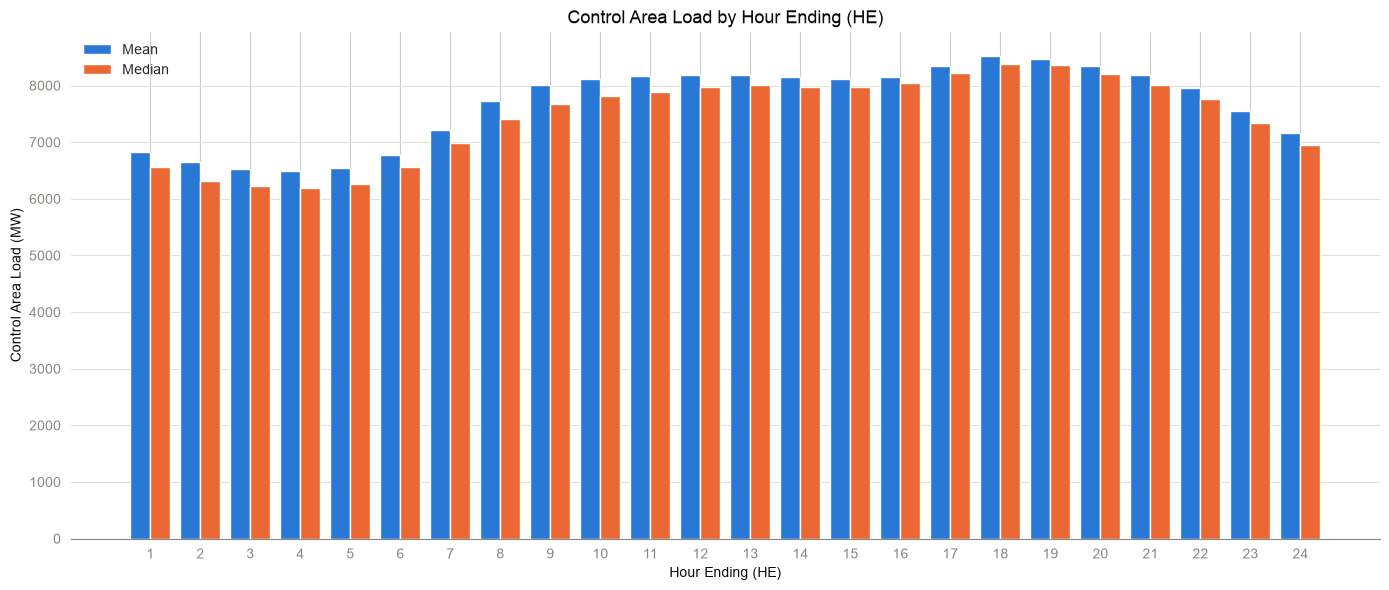

In [20]:
HE_ORDER = [str(h) for h in range(1, 25)]

he_stats = (
    df_authority_load.groupby("HE")["Control Area Load"]
    .agg(["mean", "median"])
    .reindex(HE_ORDER)
)

MEAN_COLOR = MARK_COLOR
MEDIAN_COLOR = "#eb6834"

x = np.arange(len(he_stats))
width = 0.4

fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(x - width / 2, he_stats["mean"], width, label="Mean",
       color=MEAN_COLOR, zorder=3)
ax.bar(x + width / 2, he_stats["median"], width, label="Median",
       color=MEDIAN_COLOR, zorder=3)

ax.set_title("Control Area Load by Hour Ending (HE)", fontsize=13, color="#0b0b0b")
ax.set_xlabel("Hour Ending (HE)", color="#0b0b0b")
ax.set_ylabel("Control Area Load (MW)", color="#0b0b0b")
ax.set_xticks(x)
ax.set_xticklabels(he_stats.index)
ax.grid(True, axis="y", color=GRID_COLOR, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ("top", "right", "left"):
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(MUTED)
ax.tick_params(colors=MUTED)
ax.legend(frameon=False, loc="upper left")

fig.tight_layout()
plt.show()